<a href="https://colab.research.google.com/github/brodyanderson/MATH-6020-Project/blob/main/BreastCancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
# https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original

In [11]:
url = 'https://raw.githubusercontent.com/brodyanderson/MATH-6020-Project/main/breast_cancer.csv'
df = pd.read_csv(url)

breast_cancer = pd.read_csv(url)

In [18]:
print(breast_cancer.shape)
print(breast_cancer.describe)
print(breast_cancer.dtypes)
print(breast_cancer.isnull().sum())

(683, 10)
<bound method NDFrame.describe of      Clump Thickness  Uniformity of Cell Size  Uniformity of Cell Shape  \
0                  5                        1                         1   
1                  5                        4                         4   
2                  3                        1                         1   
3                  6                        8                         8   
4                  4                        1                         1   
..               ...                      ...                       ...   
678                3                        1                         1   
679                2                        1                         1   
680                5                       10                        10   
681                4                        8                         6   
682                4                        8                         8   

     Marginal Adhesion  Single Epithelial Cell Size  Ba

In [22]:
print(breast_cancer['Class'].value_counts())
# 2 for benign
# 4 for malignant

Class
2    444
4    239
Name: count, dtype: int64


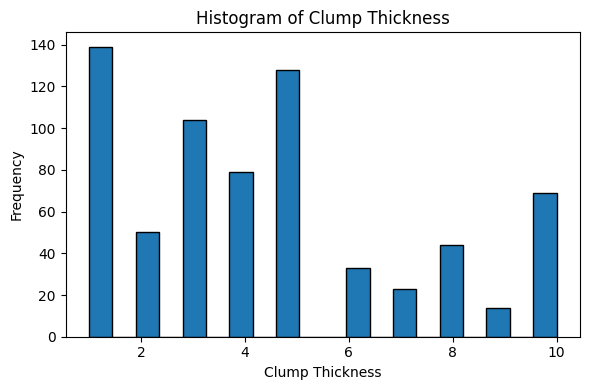

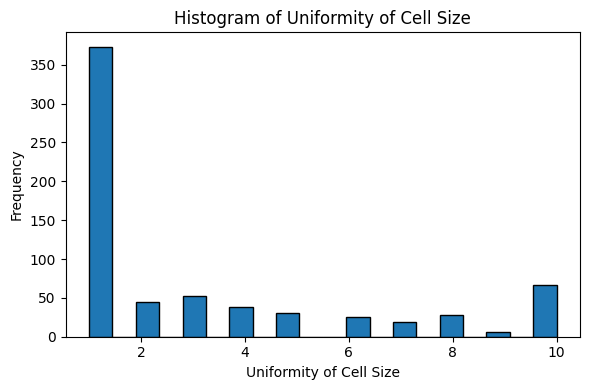

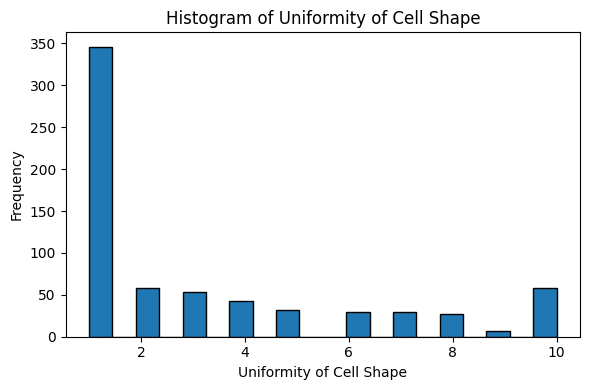

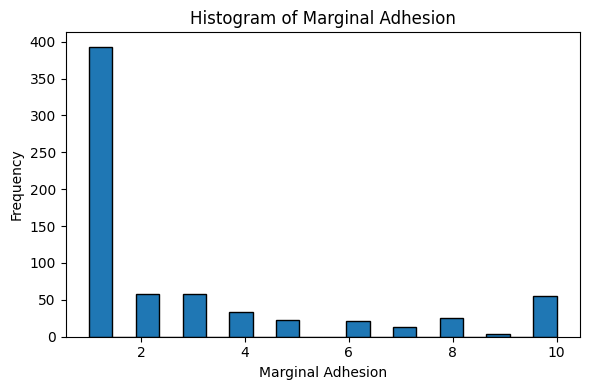

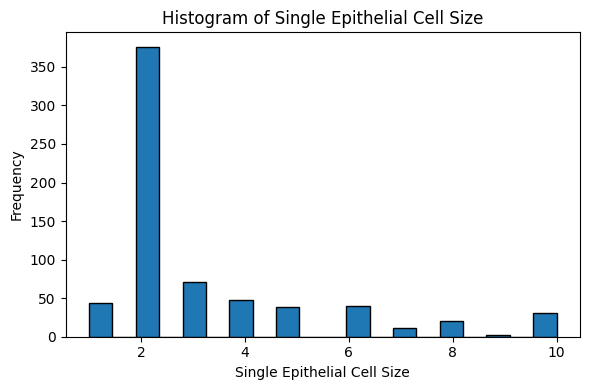

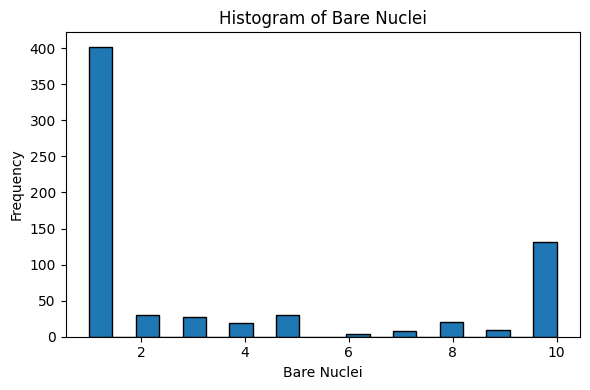

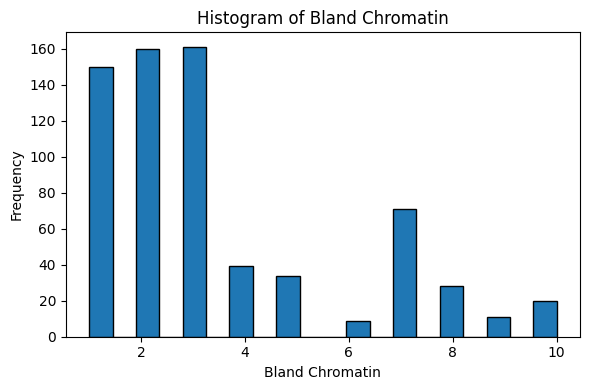

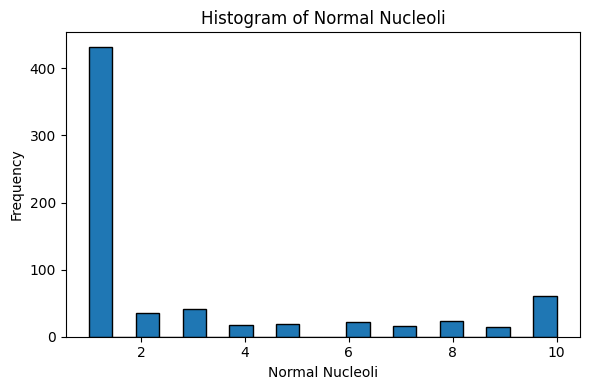

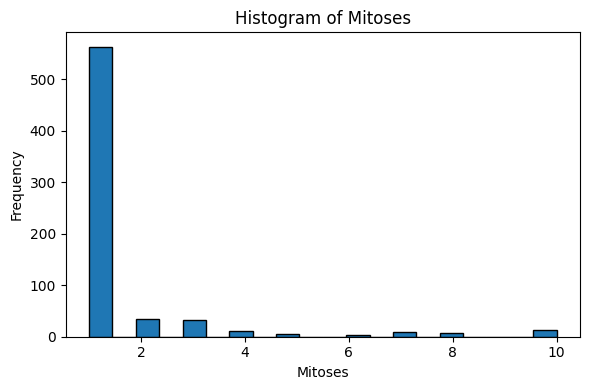

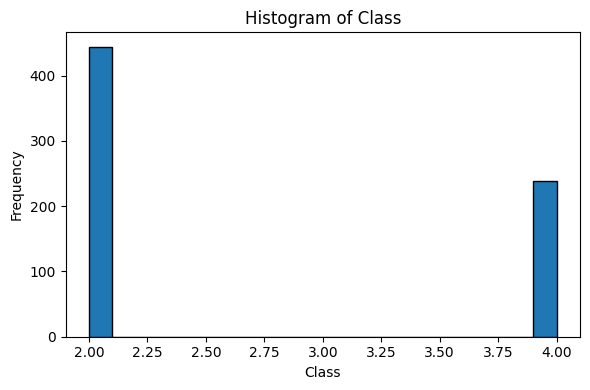

In [29]:
cols = df.drop('Class', axis=1).columns

for col in breast_cancer.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(df[col], bins=20, edgecolor='black')
    ax.set_title(f'Histogram of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()

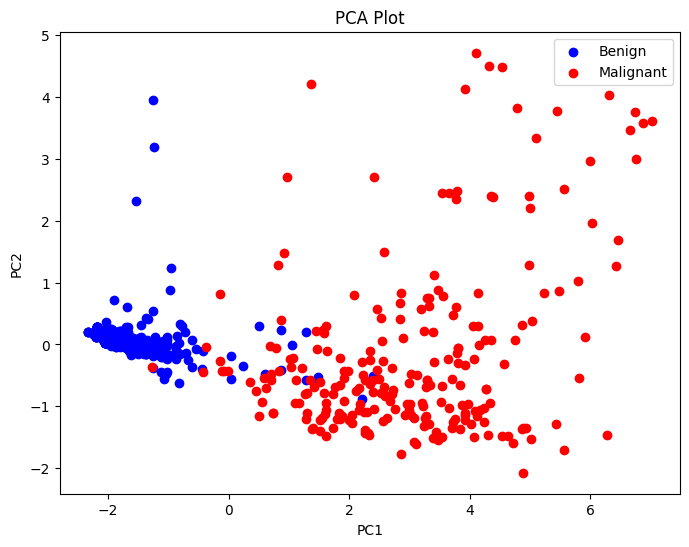

In [34]:
X = df.drop('Class', axis=1)
y = df['Class']

X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[y == 2, 0], X_pca[y == 2, 1], label='Benign', color='blue')
plt.scatter(X_pca[y == 4, 0], X_pca[y == 4, 1], label='Malignant', color='red')
plt.title('PCA Plot')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

In [40]:
pca1_variance = pca.explained_variance_ratio_[0]
pca2_variance = pca.explained_variance_ratio_[1]
pca_first_two = pca1_variance + pca2_variance

print("Variance explained by PC1:", pca1_variance.round(4))
print("Variance explained by PC2:", pca2_variance.round(4))
print("Varianced explained by PC1 & PC2:", pca_first_two.round(4))

Variance explained by PC1: 0.6555
Variance explained by PC2: 0.0862
Varianced explained by PC1 & PC2: 0.7417
